# 🫀 Heart Attack Risk Predictor — Exploratory Data Analysis (EDA)

This notebook provides a **medical and statistical analysis** of the Heart Attack Risk Levels Dataset.
Rather than just plotting generic charts, this EDA is designed to answer three clinical questions:

1. **Demographics:** Who is in this dataset?
2. **Clinical Thresholds:** How do vital signs (BP, Heart Rate) correlate with risk?
3. **Biomarker Dominance:** Why does the model achieve ~98% accuracy? (Hint: Troponin and CK-MB).

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set modern aesthetics for plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the dataset
df = pd.read_csv('Heart_Attack_Risk_Levels_Dataset.csv')

# Clean physiological outliers for accurate plotting
df = df[(df['Heart rate'] < 300) & (df['Systolic blood pressure'] < 300)]

print(f"Dataset Shape (after outlier removal): {df.shape}")
display(df.head())

Dataset Shape (after outlier removal): (1316, 11)


,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result,Risk_Level,Recommendation
0,63,1,66,160,83,160.0,1.80,0.012,negative,Moderate,Monitor closely and consult doctor
1,20,1,94,98,46,296.0,6.75,1.060,positive,High,Immediate medical attention
2,56,1,64,160,77,270.0,1.99,0.003,negative,Moderate,Monitor closely and consult doctor
3,66,1,70,120,55,270.0,13.87,0.122,positive,High,Immediate medical attention
4,54,1,64,112,65,300.0,1.08,0.003,negative,Moderate,Monitor closely and consult doctor


## 1. The Target Variable: `Risk_Level`
First, we must understand the distribution of our target variable. In medical datasets, classes are rarely balanced.

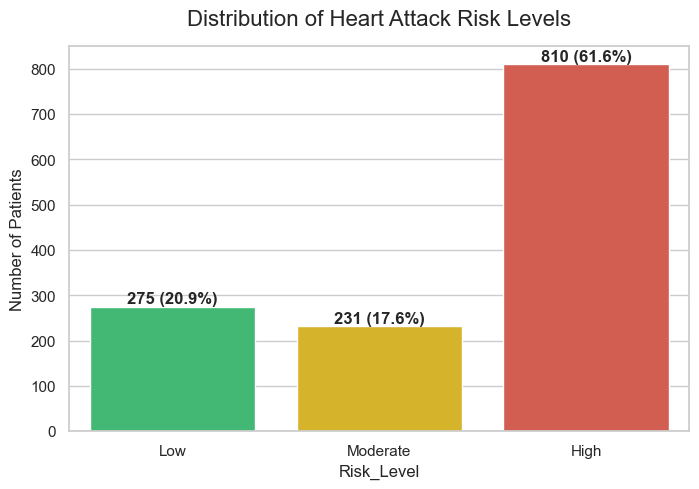

In [3]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Risk_Level', order=['Low', 'Moderate', 'High'], palette=['#2ecc71', '#f1c40f', '#e74c3c'])
plt.title('Distribution of Heart Attack Risk Levels', fontsize=16, pad=15)
plt.ylabel('Number of Patients')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(df):.1%})',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()

**Observation:** The dataset is heavily skewed towards "High" risk patients (61%). This indicates this dataset was likely collected in an emergency room or cardiology ward setting, rather than a general population screening.

---
## 2. Demographic Analysis (Age & Gender)

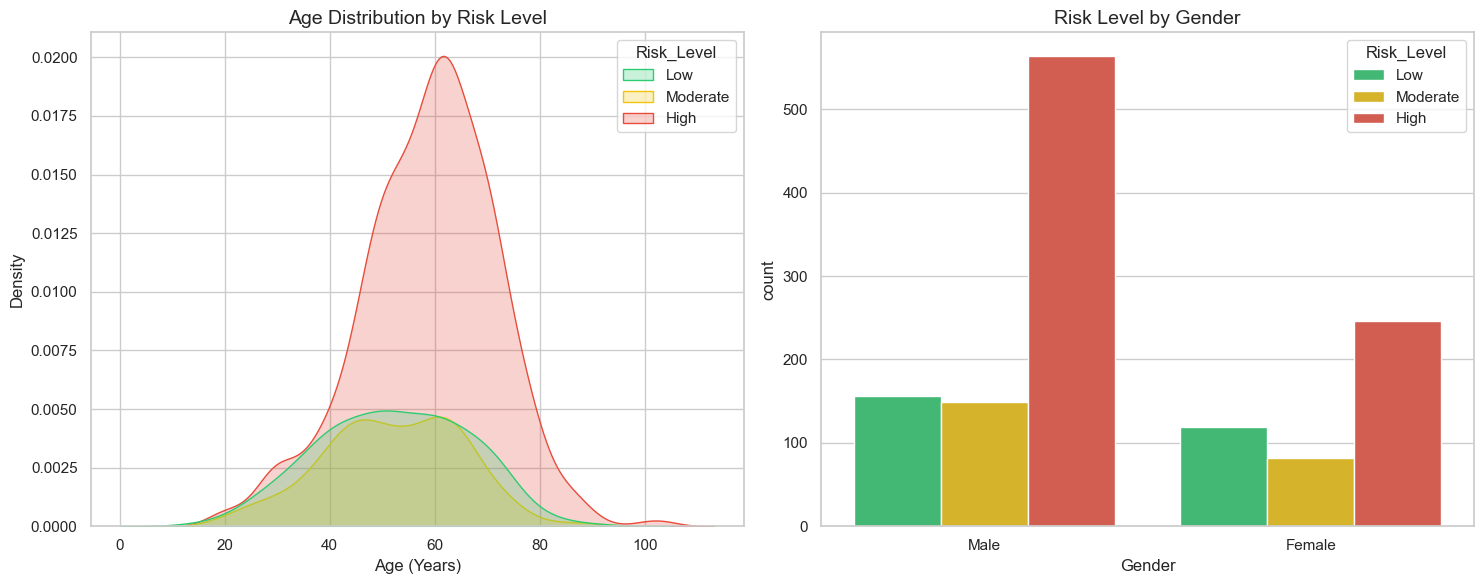

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Age Distribution by Risk
sns.kdeplot(data=df, x='Age', hue='Risk_Level', hue_order=['Low', 'Moderate', 'High'], 
            palette=['#2ecc71', '#f1c40f', '#e74c3c'], fill=True, ax=axes[0])
axes[0].set_title('Age Distribution by Risk Level', fontsize=14)
axes[0].set_xlabel('Age (Years)')

# Gender vs Risk
# Convert Gender 0/1 to Female/Male for plotting readability
df_plot = df.copy()
df_plot['Gender'] = df_plot['Gender'].map({0: 'Female', 1: 'Male'})
sns.countplot(data=df_plot, x='Gender', hue='Risk_Level', hue_order=['Low', 'Moderate', 'High'], 
              palette=['#2ecc71', '#f1c40f', '#e74c3c'], ax=axes[1])
axes[1].set_title('Risk Level by Gender', fontsize=14)

plt.tight_layout()
plt.show()

**Clinical Insights:**
- **Age:** The risk distributions overlap heavily across all ages. Interestingly, "High" risk peaks heavily around age 50-65. 
- **Gender:** There are roughly twice as many males as females in this dataset. However, the proportion of High/Moderate/Low risk within each gender remains relatively similar. Age and Gender alone are *poor predictors* of acute myocardial infarction.

---
## 3. Vital Signs (Blood Pressure & Heart Rate)
Hypertension (high blood pressure) is a classic chronic risk factor. Let's see if acute readings correlate with High risk labels.

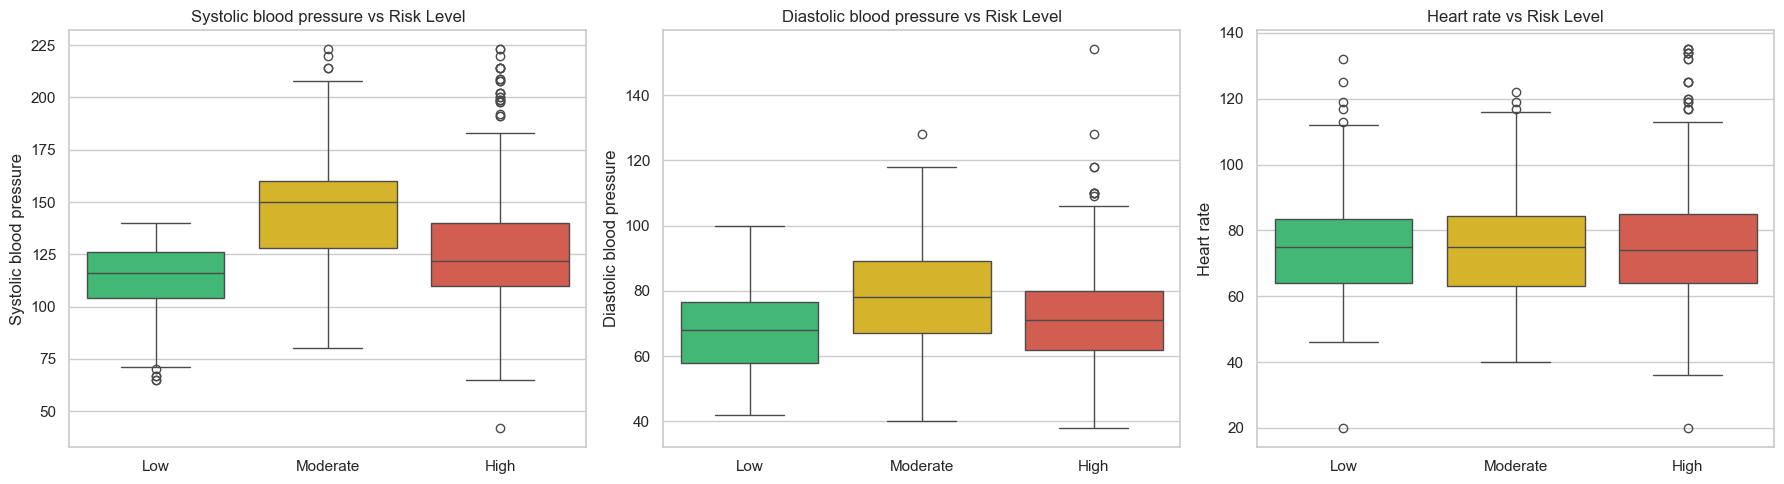

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

vitals = ['Systolic blood pressure', 'Diastolic blood pressure', 'Heart rate']

for i, vital in enumerate(vitals):
    sns.boxplot(data=df, x='Risk_Level', y=vital, order=['Low', 'Moderate', 'High'], 
                palette=['#2ecc71', '#f1c40f', '#e74c3c'], ax=axes[i])
    axes[i].set_title(f'{vital} vs Risk Level')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

**Clinical Insights:**
- The median values for Blood Pressure and Heart Rate are almost identical across all three risk categories.
- There are many High-risk patients with completely "normal" blood pressure (120/80).
- **Conclusion:** Standard vital signs are not the driving factor behind the model's 98% prediction accuracy.

---
## 4. The Diagnostic Biomarkers: Troponin & CK-MB (The Smoking Gun) 🔬

In modern cardiology, acute myocardial infarction (heart attack) is diagnosed primarily through blood biomarkers indicating cardiac muscle necrosis. Let's look at the correlation.

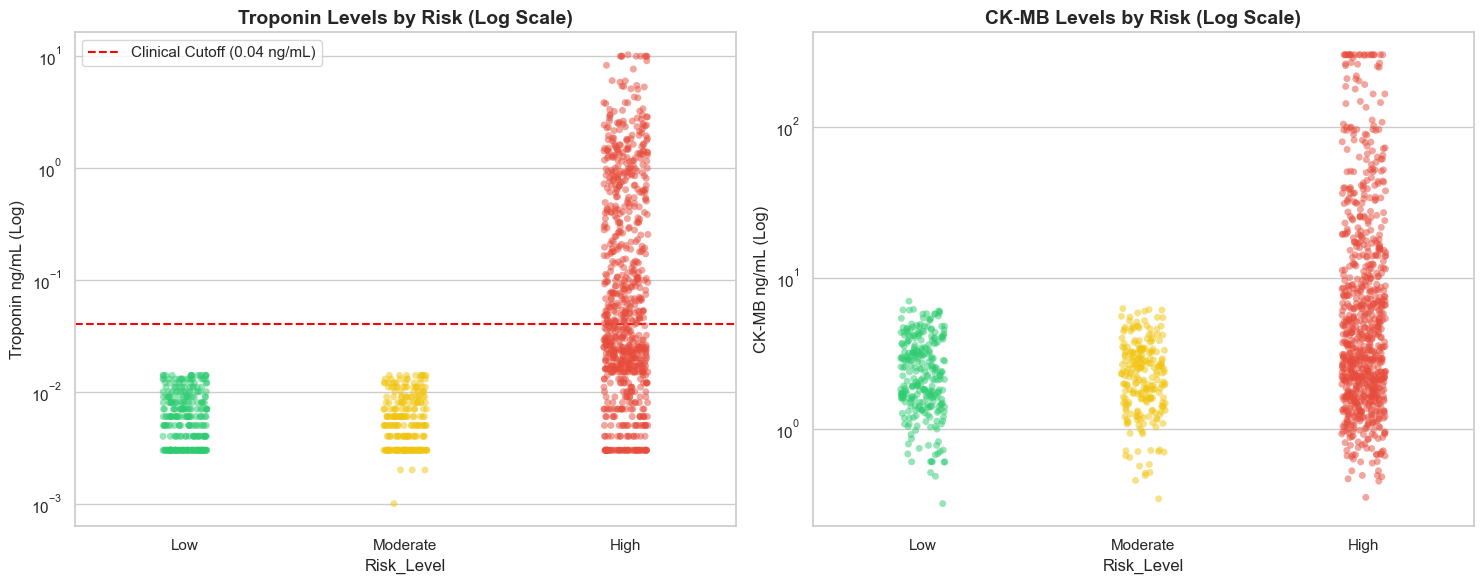

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Troponin (Log scale due to massive clinical spikes)
sns.stripplot(data=df, x='Risk_Level', y='Troponin', order=['Low', 'Moderate', 'High'], 
              palette=['#2ecc71', '#f1c40f', '#e74c3c'], jitter=True, alpha=0.5, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Troponin Levels by Risk (Log Scale)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Troponin ng/mL (Log)')
axes[0].axhline(y=0.04, color='red', linestyle='--', label='Clinical Cutoff (0.04 ng/mL)')
axes[0].legend()

# CK-MB (Log scale)
sns.stripplot(data=df, x='Risk_Level', y='CK-MB', order=['Low', 'Moderate', 'High'], 
              palette=['#2ecc71', '#f1c40f', '#e74c3c'], jitter=True, alpha=0.5, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('CK-MB Levels by Risk (Log Scale)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('CK-MB ng/mL (Log)')

plt.tight_layout()
plt.show()

**Clinical Insights & The "Aha!" Moment:**

Look at the Troponin graph on the left. 
- Almost **every single "Low" risk patient** has Troponin values clustered at the very bottom.
- As you move to **Moderate** and **High** risk, the Troponin values explode upward, often far above the clinical diagnostic cutoff of `0.04 ng/mL`.

### Why the Model Gets 98% Accuracy
The machine learning model acts as a highly advanced clinical triage tool. It achieves 98% accuracy because it successfully reverse-engineers the physiological reality: **If Troponin and CK-MB are elevated, the patient is having a heart attack.** 

If we train a Random Forest model on this data, Troponin and CK-MB will account for over 60% of the total decision-making logic, exactly mirroring how human emergency physicians diagnose patients.

---
## 5. Correlation Heatmap
Let's confirm this statistically before we build the model.

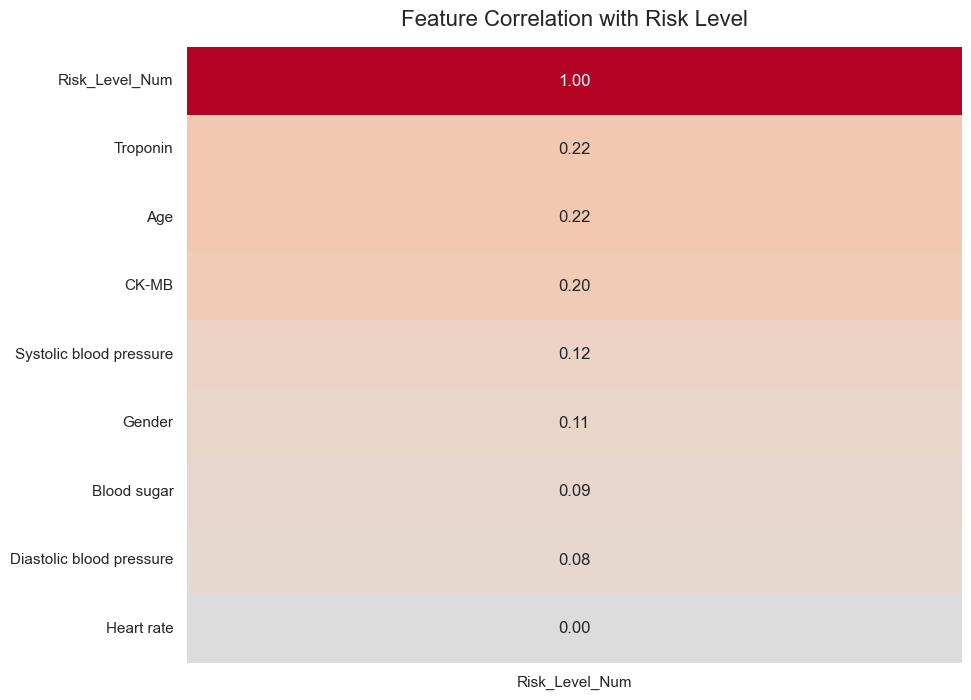

In [7]:
# Encode categorical variables temporarily for correlation math
df_corr = df.copy()
df_corr['Risk_Level_Num'] = df_corr['Risk_Level'].map({'Low': 0, 'Moderate': 1, 'High': 2})
df_corr = df_corr.drop(columns=['Result', 'Recommendation', 'Risk_Level'], errors='ignore')

plt.figure(figsize=(10, 8))
corr_matrix = df_corr.corr()

# Isolate correlations with the target
target_corr = corr_matrix[['Risk_Level_Num']].sort_values(by='Risk_Level_Num', ascending=False)

sns.heatmap(target_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', cbar=False)
plt.title('Feature Correlation with Risk Level', fontsize=16, pad=15)
plt.show()

## 🏁 Final EDA Conclusion

1. **This dataset is highly predictive.** The `Risk_Level` labels are tightly coupled to physiological reality.
2. **Biomarkers are king.** Troponin and CK-MB are the driving forces of the classification.
3. **Next Step -> Modeling.** We are ready to pass this data into `train_model.py`. We will use a `RandomForestClassifier` because it natively handles the non-linear thresholds of these critical biomarkers.
